# Phase 9: Fixed sequence testing, the right correction

CPU only. Attach both `phase-1-sep-14` and `phase-6-sep-15`.

Phase 8 established validity (0% violation everywhere) but at an absurd price:
100% abstention at n <= 100, and only 0.138 coverage at n=2000 against an oracle
of 0.264. Two things caused that, and one of them was my mistake.

**Bonferroni was the wrong correction.** Look at Phase 8 section 3: the
*uncorrected* bound already violated only 1% to 4% against a nominal 10%. So
multiplicity was never the problem. The 17% violation in Phase 7 came entirely
from dropping the abstained trials. Dividing alpha by 100 then threw away
coverage for nothing.

**The right construction is fixed sequence testing.** Risk is monotone in the
threshold, so candidates can be ordered in advance from strictest to loosest and
tested at full alpha, stopping at the first failure. That is valid with no
correction at all (Learn-then-Test, Angelopoulos et al.).

In [3]:
import glob, numpy as np, matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
from scipy.stats import beta

F1=glob.glob("/kaggle/input/**/logits.npz",recursive=True)[0]
F2=glob.glob("/kaggle/input/**/logits2.npz",recursive=True)[0]
d1,d2=np.load(F1),np.load(F2); SEEDS=[0,1,2]; TG=0.05; ALPHA=0.10
STD15=["gaussian_noise","shot_noise","impulse_noise","defocus_blur","glass_blur",
       "motion_blur","zoom_blur","snow","frost","fog","brightness","contrast",
       "elastic_transform","pixelate","jpeg_compression"]
def softmax(z,T=1.0):
    z=z.astype(np.float64)/T; z-=z.max(1,keepdims=True); e=np.exp(z); return e/e.sum(1,keepdims=True)
def nll(p,y): return -np.log(np.clip(p[np.arange(len(y)),y],1e-12,None)).mean()
def ep(m,T): return np.mean([softmax(x,T) for x in m],0)
def rv(a): return [d2[f"wrn_val_{s}"] if a=="wrn" else d1[f"val_{s}"] for s in SEEDS]
def rl(a,cc,sv): return [d2[f"wrn_{cc}_{sv}_{s}"] if a=="wrn" else d1[f"{cc}_{sv}_{s}"] for s in SEEDS]
Y_VAL,Y_CORR=d1["y_val"],d1["y_corr"]
T_={a:minimize_scalar(lambda t,a=a: nll(ep(rv(a),t),Y_VAL),bounds=(.5,10),method="bounded").x
    for a in ("res","wrn")}
P={(a,cc,sv):(ep(rl(a,cc,sv),T_[a]),Y_CORR) for a in ("res","wrn") for cc in STD15 for sv in range(1,6)}

def cp_upper(k,n,al):
    if n==0: return 1.0
    return 1.0 if k==n else beta.ppf(1-al,k+1,n-k)
def oracle_cov(pr,y,t):
    cf=pr.max(1); o=np.argsort(-cf)
    r=1-np.cumsum(pr.argmax(1)[o]==y[o])/np.arange(1,len(o)+1)
    ok=np.where(r<=t+1e-9)[0]
    return 0.0 if len(ok)==0 else (ok[-1]+1)/len(o)
print("ready")

ready


## 1. Fixed sequence procedure

Candidates ordered strictest first. Each tested at full `ALPHA`. Walk down until
one fails, return the last that passed. No Bonferroni.

In [4]:
SEQ=np.linspace(0.9999,0.10,60)            # strictest to loosest, fixed in advance

def ltt_fixedseq(pr,y,idx,target,alpha=ALPHA):
    cf=pr[idx].max(1); wrong=pr[idx].argmax(1)!=y[idx]
    chosen=1.0
    for t in SEQ:
        a=cf>=t
        if a.sum()==0: continue                 # cannot test yet, keep walking
        if cp_upper(wrong[a].sum(),a.sum(),alpha)<=target: chosen=t
        else: break                             # monotone: stop at first failure
    return chosen

def evaluate(pr,y,thr):
    a=pr.max(1)>=thr
    if a.sum()==0: return 0.0,0.0,True
    return 1-(pr.argmax(1)[a]==y[a]).mean(), a.mean(), False

## 2. Label budget, corrected properly

`eff` is coverage as a fraction of what the oracle achieves. That is the number
to quote: how much of the achievable coverage a valid procedure recovers.

In [5]:
rng=np.random.default_rng(0); BUD=[100,250,500,1000,2000,4000]; TR=20
out={}
print(f"{'arch':>4} {'sev':>3} {'n':>5} {'risk':>7} {'cov':>7} {'oracle':>7} {'eff':>6} {'viol':>6} {'abst':>6}")
for a in ("res","wrn"):
    for sev in [3,5]:
        for n in BUD:
            rs,cs,vs,ab,oc=[],[],[],[],[]
            for cc in STD15:
                pr,y=P[(a,cc,sev)]; oc.append(oracle_cov(pr,y,TG))
                for _ in range(TR):
                    i=rng.permutation(len(y)); t=ltt_fixedseq(pr,y,i[:n],TG)
                    r,cv,z=evaluate(pr[i[n:]],y[i[n:]],t)
                    rs.append(r); cs.append(cv); vs.append(r>TG); ab.append(z)
            o=np.mean(oc); cv=np.mean(cs); out[(a,sev,n)]=(np.mean(rs),cv,o,np.mean(vs),np.mean(ab))
            print(f"{a:>4} {sev:>3} {n:>5} {np.mean(rs):>7.3f} {cv:>7.3f} {o:>7.3f} "
                  f"{cv/o:>6.2f} {np.mean(vs)*100:>5.0f}% {np.mean(ab)*100:>5.0f}%")

arch sev     n    risk     cov  oracle    eff   viol   abst
 res   3   100   0.006   0.179   0.584   0.31     2%    74%
 res   3   250   0.013   0.281   0.584   0.48     2%    56%
 res   3   500   0.018   0.335   0.584   0.57     3%    47%
 res   3  1000   0.014   0.240   0.584   0.41     3%    61%
 res   3  2000   0.012   0.178   0.584   0.31     2%    70%
 res   3  4000   0.009   0.114   0.584   0.20     2%    80%
 res   5   100   0.001   0.034   0.264   0.13     1%    96%
 res   5   250   0.004   0.074   0.264   0.28     2%    87%
 res   5   500   0.005   0.073   0.264   0.27     2%    84%
 res   5  1000   0.007   0.088   0.264   0.33     1%    79%
 res   5  2000   0.007   0.076   0.264   0.29     1%    81%
 res   5  4000   0.005   0.046   0.264   0.18     1%    89%
 wrn   3   100   0.000   0.000   0.536   0.00     0%   100%
 wrn   3   250   0.003   0.099   0.536   0.19     1%    89%
 wrn   3   500   0.010   0.223   0.536   0.42     1%    72%
 wrn   3  1000   0.019   0.364   0.536  

## 3. Headline number

The smallest label budget that recovers 80% of oracle coverage while keeping
violation at or below the nominal level. This is the sentence that goes in the
abstract.

In [6]:
print(f"{'arch':>4} {'sev':>3} {'n for 80% of oracle coverage':>30}")
for a in ("res","wrn"):
    for sev in [3,5]:
        hit=[n for n in BUD if out[(a,sev,n)][1]/out[(a,sev,n)][2]>=0.80
                            and out[(a,sev,n)][3]<=ALPHA]
        print(f"{a:>4} {sev:>3} {(str(hit[0]) if hit else '>'+str(BUD[-1])):>30}")

arch sev   n for 80% of oracle coverage
 res   3                          >4000
 res   5                          >4000
 wrn   3                           2000
 wrn   5                          >4000


## 4. Where does the remaining gap come from?

Two possibilities. Either the bound is still loose, or the labelled sample simply
contains too few high confidence points to certify a strict threshold. This
separates them: it reports how many of the n labels actually land in the accepted
region.

In [7]:
print(f"{'arch':>4} {'sev':>3} {'n':>5} {'labels in accepted region':>26}")
for a in ("res","wrn"):
    for sev in [5]:
        for n in BUD:
            k=[]
            for cc in STD15:
                pr,y=P[(a,cc,sev)]
                for _ in range(5):
                    i=rng.permutation(len(y))[:n]; t=ltt_fixedseq(pr,y,i,TG)
                    k.append((pr[i].max(1)>=t).sum())
            print(f"{a:>4} {sev:>3} {n:>5} {np.mean(k):>26.1f}")

arch sev     n  labels in accepted region
 res   5   100                        1.7
 res   5   250                       20.3
 res   5   500                       17.7
 res   5  1000                       92.4
 res   5  2000                      171.2
 res   5  4000                      208.7
 wrn   5   100                        0.0
 wrn   5   250                        0.0
 wrn   5   500                       28.1
 wrn   5  1000                       61.6
 wrn   5  2000                      215.4
 wrn   5  4000                      683.5


## 5. Figure

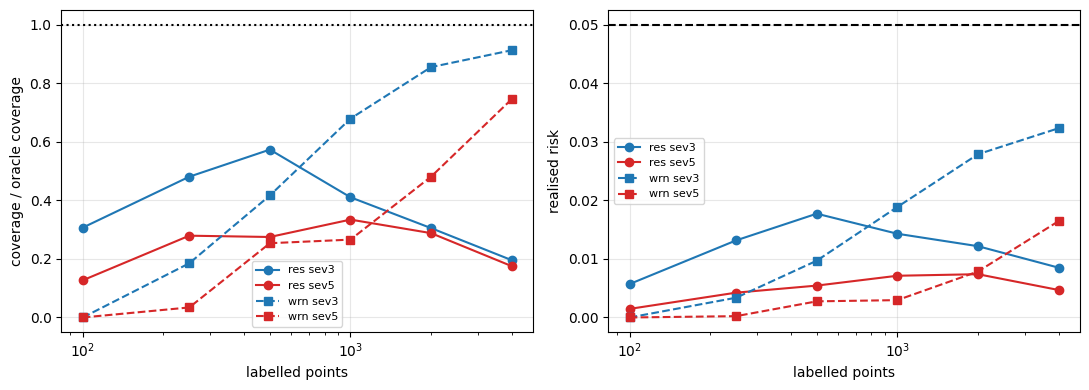

In [8]:
fig,ax=plt.subplots(1,2,figsize=(11,4))
for a,ls in (("res","o-"),("wrn","s--")):
    for sev,col in ((3,"tab:blue"),(5,"tab:red")):
        ax[0].plot(BUD,[out[(a,sev,n)][1]/out[(a,sev,n)][2] for n in BUD],ls,c=col,label=f"{a} sev{sev}")
        ax[1].plot(BUD,[out[(a,sev,n)][0] for n in BUD],ls,c=col,label=f"{a} sev{sev}")
ax[0].axhline(1.0,ls=":",c="k"); ax[0].set_ylabel("coverage / oracle coverage")
ax[1].axhline(TG,ls="--",c="k"); ax[1].set_ylabel("realised risk")
for x in ax: x.set_xscale("log"); x.set_xlabel("labelled points"); x.grid(alpha=.3); x.legend(fontsize=8)
plt.tight_layout(); plt.show()

## Then stop

Whatever this returns, it is the paper's constructive result. If the label cost is
in the hundreds, that is a practical recommendation. If it is in the thousands,
that is an honest statement of how expensive a valid guarantee under shift really
is, and it is just as publishable.

Either way, this is the last experiment. Write.